In [31]:
# AudDSR Paper-Aligned Implementation
# ====================================
# Two-stage training pipeline:
# Stage 1: Discrete VQ-VAE autoencoder on all machine types (general feature space)
# Stage 2: Anomaly detector + object-specific decoder on all machine types
#
# This notebook implements the exact architecture and training flow from the AudDSR paper.

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AudDSRMock().to(device)
model.eval()

batch_size = 4
sample_input = torch.randn(batch_size, 1, 128, 128, device=device)

with torch.no_grad():
    anomaly_map, latent_mask = model(sample_input)

print(f"Device: {device}")
print(f"Input shape: {tuple(sample_input.shape)}")
print(f"Anomaly map shape: {tuple(anomaly_map.shape)}")
print(f"Latent mask shape: {tuple(latent_mask.shape)}")
print(
    "Anomaly map stats: "
    f"min={anomaly_map.min().item():.4f}, "
    f"max={anomaly_map.max().item():.4f}, "
    f"mean={anomaly_map.mean().item():.4f}"
)


Device: cpu
Input shape: (4, 1, 128, 128)
Anomaly map shape: (4, 1, 128, 128)
Latent mask shape: (4, 1, 32, 32)
Anomaly map stats: min=0.3551, max=0.5455, mean=0.4406


## Run The Model On The Entire Training Set

This section runs inference on all WAV files under the selected machine's training folder.

The workflow is:
- find every WAV file in train
- load each file, convert to mono, and resample to 16 kHz
- convert to a 128x128 log-mel spectrogram
- run the model for each file and compute an anomaly score
- report score statistics over the full training set
- visualize one selected file from that full-set run


In [33]:
import os
import numpy as np
import torchaudio
import torchaudio.transforms as T
from scipy.io import wavfile

DATA_ROOT = r"C:\Users\20223669\OneDrive - TU Eindhoven\Desktop\Soroma Internship\15097779"
MACHINE_TYPE = "bearing"
TARGET_SR = 16_000
N_MELS = 128
SPEC_SIZE = 128
VISUALIZE_INDEX = 0


def collect_wav_files(folder):
    wav_paths = []
    for root, _, files in os.walk(folder):
        for file_name in files:
            if file_name.lower().endswith(".wav"):
                wav_paths.append(os.path.join(root, file_name))
    return sorted(wav_paths)


def load_waveform(path, target_sr=TARGET_SR):
    try:
        waveform, sample_rate = torchaudio.load(path)
    except (RuntimeError, ImportError, OSError):
        sample_rate, data = wavfile.read(path)
        data = np.asarray(data)
        if np.issubdtype(data.dtype, np.integer):
            data = data.astype(np.float32) / float(np.iinfo(data.dtype).max)
        else:
            data = data.astype(np.float32)
        waveform = torch.from_numpy(data).unsqueeze(0) if data.ndim == 1 else torch.from_numpy(data.T)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sample_rate != target_sr:
        waveform = torchaudio.functional.resample(waveform, sample_rate, target_sr)
    return waveform.squeeze(0)


def waveform_to_model_input(waveform, mel_transform):
    spec = torch.log1p(mel_transform(waveform)).unsqueeze(0).unsqueeze(0)
    spec = F.interpolate(
        spec,
        size=(SPEC_SIZE, SPEC_SIZE),
        mode="bilinear",
        align_corners=False,
    )
    return spec


mel_transform = T.MelSpectrogram(
    sample_rate=TARGET_SR,
    n_fft=1024,
    hop_length=512,
    n_mels=N_MELS,
)

train_dir = os.path.join(DATA_ROOT, f"dev_{MACHINE_TYPE}", MACHINE_TYPE, "train")
wav_files = collect_wav_files(train_dir)
if not wav_files:
    raise FileNotFoundError(f"No WAV files found in {train_dir}")

if VISUALIZE_INDEX < 0 or VISUALIZE_INDEX >= len(wav_files):
    raise IndexError(f"VISUALIZE_INDEX must be in [0, {len(wav_files)-1}]")

model.eval()
anomaly_scores = []
selected_file = wav_files[VISUALIZE_INDEX]
selected_input = None
selected_anomaly_map = None
selected_latent_mask = None

with torch.no_grad():
    for idx, wav_path in enumerate(wav_files):
        waveform = load_waveform(wav_path)
        model_input = waveform_to_model_input(waveform, mel_transform).to(device)
        anomaly_map, latent_mask = model(model_input)

        # Scalar file-level score from the anomaly map
        anomaly_scores.append(float(anomaly_map.mean().item()))

        if idx == VISUALIZE_INDEX:
            selected_input = model_input.detach().cpu()
            selected_anomaly_map = anomaly_map.detach().cpu()
            selected_latent_mask = latent_mask.detach().cpu()

anomaly_scores = np.asarray(anomaly_scores, dtype=np.float32)

print(f"Processed files: {len(wav_files)}")
print(f"Selected file for plotting: {os.path.basename(selected_file)}")
print(
    "Anomaly score stats over full training set: "
    f"min={anomaly_scores.min():.4f}, "
    f"mean={anomaly_scores.mean():.4f}, "
    f"max={anomaly_scores.max():.4f}, "
    f"std={anomaly_scores.std():.4f}"
)

# Show top-5 highest-scoring files for quick inspection
ranked_idx = np.argsort(anomaly_scores)[::-1][:5]
print("Top-5 files by anomaly score:")
for rank, file_idx in enumerate(ranked_idx, start=1):
    print(f"{rank}. {os.path.basename(wav_files[file_idx])}  score={anomaly_scores[file_idx]:.4f}")


Processed files: 1000
Selected file for plotting: section_00_source_train_normal_0000_noAttribute.wav
Anomaly score stats over full training set: min=0.4398, mean=0.4401, max=0.4403, std=0.0001
Top-5 files by anomaly score:
1. section_00_source_train_normal_0291_noAttribute.wav  score=0.4403
2. section_00_source_train_normal_0843_noAttribute.wav  score=0.4403
3. section_00_source_train_normal_0256_noAttribute.wav  score=0.4403
4. section_00_source_train_normal_0480_noAttribute.wav  score=0.4402
5. section_00_source_train_normal_0804_noAttribute.wav  score=0.4402


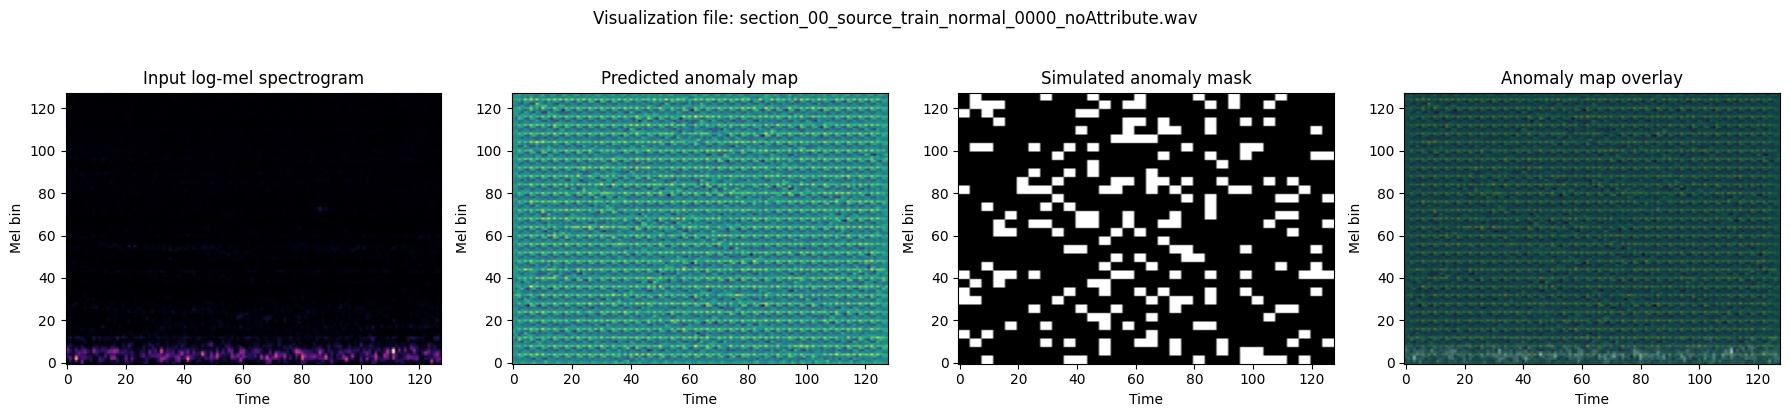

In [34]:
import matplotlib.pyplot as plt

input_image = selected_input.squeeze().numpy()
anomaly_image = selected_anomaly_map.squeeze().numpy()
mask_image = F.interpolate(
    selected_latent_mask.float(),
    size=(SPEC_SIZE, SPEC_SIZE),
    mode="nearest",
).squeeze().numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(input_image, origin="lower", aspect="auto", cmap="magma")
axes[0].set_title("Input log-mel spectrogram")

axes[1].imshow(anomaly_image, origin="lower", aspect="auto", cmap="viridis")
axes[1].set_title("Predicted anomaly map")

axes[2].imshow(mask_image, origin="lower", aspect="auto", cmap="gray")
axes[2].set_title("Simulated anomaly mask")

axes[3].imshow(input_image, origin="lower", aspect="auto", cmap="gray")
axes[3].imshow(anomaly_image, origin="lower", aspect="auto", cmap="viridis", alpha=0.5)
axes[3].set_title("Anomaly map overlay")

for ax in axes:
    ax.set_xlabel("Time")
    ax.set_ylabel("Mel bin")

plt.suptitle(f"Visualization file: {os.path.basename(selected_file)}", y=1.03)
plt.tight_layout()
plt.show()


## Paper-Aligned Implementation: Two-Stage AudDSR Training

This notebook implements the paper's training pipeline:

**Stage 1:** Train a discrete VQ-VAE autoencoder on all machine types to learn a general feature space.

**Stage 2:** Freeze the encoder and train:
- Object-specific decoder (influenced by band_time anomalies)
- Anomaly detector head (predicts anomaly map)

**Key components:**
- Discrete VQ-VAE with two-level quantization (Q1, Q2) for hierarchical features
- Band-time anomaly mask (audio-aligned corruption pattern)
- Focal loss for imbalanced anomaly detection
- Multi-machine training for robust cross-domain detection



In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from scipy.io import wavfile
from sklearn.metrics import roc_auc_score
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Experiment options
# -----------------------------

# (4) Quantizer capacity options.
QUANTIZER_OPTIONS = {
    "tiny":   {"q1_embeddings": 128,  "q2_embeddings": 128},
    "small":  {"q1_embeddings": 256,  "q2_embeddings": 256},
    "base":   {"q1_embeddings": 512,  "q2_embeddings": 512},
    "large":  {"q1_embeddings": 1024, "q2_embeddings": 1024},
    "xlarge": {"q1_embeddings": 2048, "q2_embeddings": 2048},
}
SELECTED_QUANTIZER = "base"

# (6) Frontend options from the paper setup family.
FRONTEND_OPTIONS = {
    "transient": {"n_fft": 512,  "hop_length": 128, "n_mels": 128, "norm": "per_bin"},
    "balanced":  {"n_fft": 1024, "hop_length": 256, "n_mels": 128, "norm": "per_bin"},
    "harmonic":  {"n_fft": 2048, "hop_length": 512, "n_mels": 128, "norm": "global"},
    "low_compute": {"n_fft": 512, "hop_length": 256, "n_mels": 64, "norm": "none"},
}
SELECTED_FRONTEND = "balanced"

# (3.3) Anomaly mask generation processes.
# - perlin_like: smooth random map thresholding
# - band_time: random frequency band + several time segments (closest to the paper's dedicated audio mask process)
CORRUPTION_OPTIONS = {
    "perlin_like": {
        "mode": "perlin_like",
        "ratio": 0.20,
        "block_hw": (8, 8),
        "low_res": (8, 8),
    },
    "band_time": {
        "mode": "band_time",
        "ratio": 0.20,
        "block_hw": (8, 8),
        "low_res": (8, 8),
    },
    "point": {"mode": "point", "ratio": 0.20, "block_hw": (4, 4), "low_res": (8, 8)},
    "time_stripe": {"mode": "time_stripe", "ratio": 0.20, "block_hw": (4, 16), "low_res": (8, 8)},
    "freq_stripe": {"mode": "freq_stripe", "ratio": 0.20, "block_hw": (16, 4), "low_res": (8, 8)},
    "block_medium": {"mode": "block", "ratio": 0.20, "block_hw": (8, 8), "low_res": (8, 8)},
}
SELECTED_CORRUPTION = "band_time"

# (5) Detector width options. Paper detector input is concat(XG, XS).
DETECTOR_OPTIONS = {
    "light": {"width": 32},
    "wide": {"width": 64},
}
SELECTED_DETECTOR = "light"

# Paths and runtime settings
DATA_ROOT = r"C:\Users\20223669\OneDrive - TU Eindhoven\Desktop\Soroma Internship\15097779"
ALL_MACHINE_TYPES = ["bearing", "fan", "gearbox", "slider", "ToyCar", "ToyTrain", "valve"]

# Paper-mimic split strategy:
# - Stage 1 learns a general discrete latent space from all machine types.
# - Stage 2 is also trained/evaluated on ALL machine types (multi-machine anomaly detection).
STAGE1_MACHINE_TYPES = ALL_MACHINE_TYPES
STAGE2_MACHINE_TYPES = ALL_MACHINE_TYPES  # Train on all machine types for robust detection

TARGET_SR = 16_000
SPEC_SIZE = 128
BATCH_SIZE = 16
VISUALIZE_INDEX = 0
TOPK_RATIO = 0.05

# Ensure this section can run independently.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Stage 1 (discrete autoencoder) paper-like defaults.
STAGE1_EPOCHS = 5       # paper uses long iteration training; keep small for notebook runtime
LR_STAGE1 = 2e-4
LAMBDA_X = 1.0
LAMBDA_K = 0.25

# Stage 2 (AudDSR) paper-like defaults.
STAGE2_EPOCHS = 5
LR_STAGE2 = 2e-4
STAGE2_ANOMALY_BATCH_RATIO = 0.5   # paper trains with half anomalous and half clean samples per batch
LAMBDA_STAGE2_REC = 1.0
LAMBDA_STAGE2_DET = 5.0 
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0

q_cfg = QUANTIZER_OPTIONS[SELECTED_QUANTIZER]
f_cfg = FRONTEND_OPTIONS[SELECTED_FRONTEND]
c_cfg = CORRUPTION_OPTIONS[SELECTED_CORRUPTION]
d_cfg = DETECTOR_OPTIONS[SELECTED_DETECTOR]

print("Selected options:")
print(f"- device:          {device}")
print(f"- quantizer:       {SELECTED_QUANTIZER} -> {q_cfg}")
print(f"- frontend:        {SELECTED_FRONTEND} -> {f_cfg}")
print(f"- corruption:      {SELECTED_CORRUPTION} -> {c_cfg}")
print(f"- detector:        {SELECTED_DETECTOR} -> {d_cfg}")
print(f"- stage1 machines: {STAGE1_MACHINE_TYPES}")
print(f"- stage2 machines: {STAGE2_MACHINE_TYPES}")
print(f"- stage1 epochs/lr:{STAGE1_EPOCHS} / {LR_STAGE1}")
print(f"- stage2 epochs/lr:{STAGE2_EPOCHS} / {LR_STAGE2}")
print(f"- detector weight: {LAMBDA_STAGE2_DET}")
print(f"- stage2 anom frac:{STAGE2_ANOMALY_BATCH_RATIO}")


Selected options:
- device:          cpu
- quantizer:       base -> {'q1_embeddings': 512, 'q2_embeddings': 512}
- frontend:        balanced -> {'n_fft': 1024, 'hop_length': 256, 'n_mels': 128, 'norm': 'per_bin'}
- corruption:      band_time -> {'mode': 'band_time', 'ratio': 0.2, 'block_hw': (8, 8), 'low_res': (8, 8)}
- detector:        light -> {'width': 32}
- stage1 machines: ['bearing', 'fan', 'gearbox', 'slider', 'ToyCar', 'ToyTrain', 'valve']
- stage2 machines: ['bearing', 'fan', 'gearbox', 'slider', 'ToyCar', 'ToyTrain', 'valve']
- stage1 epochs/lr:5 / 0.0002
- stage2 epochs/lr:5 / 0.0002
- detector weight: 5.0
- stage2 anom frac:0.5


In [36]:
def collect_wav_files(folder):
    wav_paths = []
    for root, _, files in os.walk(folder):
        for file_name in files:
            if file_name.lower().endswith(".wav"):
                wav_paths.append(os.path.join(root, file_name))
    return sorted(wav_paths)


def collect_machine_split_files(data_root, machine_type, split):
    split_dir = os.path.join(data_root, f"dev_{machine_type}", machine_type, split)
    return collect_wav_files(split_dir)


def collect_multi_machine_split_files(data_root, machine_types, split):
    files = []
    for machine in machine_types:
        files.extend(collect_machine_split_files(data_root, machine, split))
    return sorted(files)


def infer_machine_type_from_path(path):
    path_lower = path.replace("\\", "/").lower()
    for machine in ALL_MACHINE_TYPES:
        token = f"/dev_{machine.lower()}/"
        if token in path_lower:
            return machine
    return "unknown"


def load_waveform(path, target_sr=TARGET_SR):
    try:
        waveform, sample_rate = torchaudio.load(path)
    except (RuntimeError, ImportError, OSError):
        sample_rate, data = wavfile.read(path)
        data = np.asarray(data)
        if np.issubdtype(data.dtype, np.integer):
            data = data.astype(np.float32) / float(np.iinfo(data.dtype).max)
        else:
            data = data.astype(np.float32)
        waveform = torch.from_numpy(data).unsqueeze(0) if data.ndim == 1 else torch.from_numpy(data.T)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sample_rate != target_sr:
        waveform = torchaudio.functional.resample(waveform, sample_rate, target_sr)
    return waveform.squeeze(0)


def normalize_spec(spec, mode):
    # spec shape: (1, n_mels, time)
    if mode == "none":
        return spec
    if mode == "global":
        mean = spec.mean()
        std = spec.std().clamp_min(1e-6)
        return (spec - mean) / std
    if mode == "per_bin":
        mean = spec.mean(dim=-1, keepdim=True)
        std = spec.std(dim=-1, keepdim=True).clamp_min(1e-6)
        return (spec - mean) / std
    raise ValueError(f"Unknown normalization mode: {mode}")


def build_mel_transform(frontend_cfg):
    return T.MelSpectrogram(
        sample_rate=TARGET_SR,
        n_fft=frontend_cfg["n_fft"],
        hop_length=frontend_cfg["hop_length"],
        n_mels=frontend_cfg["n_mels"],
    )


def waveform_to_model_input(waveform, mel_transform, frontend_cfg):
    spec = torch.log1p(mel_transform(waveform)).unsqueeze(0)  # (1, n_mels, time)
    spec = normalize_spec(spec, frontend_cfg["norm"])
    spec = F.interpolate(
        spec.unsqueeze(0),
        size=(SPEC_SIZE, SPEC_SIZE),
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)  # (1, H, W)
    return spec


class SpectrogramFileDataset(Dataset):
    def __init__(self, file_paths, mel_transform, frontend_cfg):
        self.file_paths = file_paths
        self.mel_transform = mel_transform
        self.frontend_cfg = frontend_cfg

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        waveform = load_waveform(file_path)
        spec = waveform_to_model_input(waveform, self.mel_transform, self.frontend_cfg)
        return spec, file_path


def make_corruption_mask(
    z_q,
    mode="band_time",
    ratio=0.2,
    block_hw=(8, 8),
    low_res=(8, 8),
    anomaly_batch_ratio=1.0,
):
    bsz, _, h, w = z_q.shape
    device = z_q.device
    mask = torch.zeros((bsz, 1, h, w), device=device, dtype=torch.bool)

    if anomaly_batch_ratio <= 0:
        return mask

    n_anom = int(round(anomaly_batch_ratio * bsz))
    if anomaly_batch_ratio > 0 and n_anom == 0:
        n_anom = 1
    n_anom = max(0, min(bsz, n_anom))

    active = torch.zeros((bsz,), device=device, dtype=torch.bool)
    if n_anom > 0:
        active_idx = torch.randperm(bsz, device=device)[:n_anom]
        active[active_idx] = True

    for b in range(bsz):
        if not bool(active[b].item()):
            continue

        if mode == "point":
            mask[b] = torch.rand((1, h, w), device=device) < ratio
            continue

        if mode == "time_stripe":
            stripe_w = max(1, int(w * ratio))
            start_w = int(torch.randint(0, max(1, w - stripe_w + 1), (1,), device=device).item())
            mask[b, :, :, start_w : start_w + stripe_w] = True
            continue

        if mode == "freq_stripe":
            stripe_h = max(1, int(h * ratio))
            start_h = int(torch.randint(0, max(1, h - stripe_h + 1), (1,), device=device).item())
            mask[b, :, start_h : start_h + stripe_h, :] = True
            continue

        if mode == "block":
            block_h, block_w = block_hw
            target_area = max(1, int(ratio * h * w))
            block_area = max(1, block_h * block_w)
            num_blocks = max(1, target_area // block_area)

            for _ in range(num_blocks):
                top = int(torch.randint(0, max(1, h - block_h + 1), (1,), device=device).item())
                left = int(torch.randint(0, max(1, w - block_w + 1), (1,), device=device).item())
                mask[b, :, top : top + block_h, left : left + block_w] = True
            continue

        if mode == "perlin_like":
            low_h = max(2, min(h, int(low_res[0])))
            low_w = max(2, min(w, int(low_res[1])))
            coarse = torch.rand((1, 1, low_h, low_w), device=device)
            smooth = F.interpolate(coarse, size=(h, w), mode="bicubic", align_corners=False)[0, 0]
            threshold = torch.quantile(smooth.flatten(), 1.0 - ratio)
            mask[b, 0] = smooth >= threshold
            continue

        if mode == "band_time":
            # Audio-specific mask: contiguous frequency band + several time chunks.
            band_h_min = max(1, int(0.10 * h))
            band_h_max = max(band_h_min, int(0.50 * h))
            band_h = int(torch.randint(band_h_min, band_h_max + 1, (1,), device=device).item())
            top = int(torch.randint(0, max(1, h - band_h + 1), (1,), device=device).item())

            seg_min = max(1, int(0.05 * w))
            seg_max = max(seg_min, int(0.25 * w))
            num_segments = int(torch.randint(2, 6, (1,), device=device).item())
            for _ in range(num_segments):
                seg_w = int(torch.randint(seg_min, seg_max + 1, (1,), device=device).item())
                left = int(torch.randint(0, max(1, w - seg_w + 1), (1,), device=device).item())
                mask[b, :, top : top + band_h, left : left + seg_w] = True
            continue

        raise ValueError(f"Unknown corruption mode: {mode}")

    return mask


In [37]:
class FeatureEncoder(nn.Module):
    def __init__(self, in_ch=1, ch1=64, ch2=128):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_ch, ch1, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(ch1, ch2, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        f1 = self.enc1(x)  # 128 -> 64
        f2 = self.enc2(f1)  # 64 -> 32
        return f1, f2


class VectorQuantizerSimple(nn.Module):
    def __init__(self, num_embeddings, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)

    def forward(self, z):
        bsz, ch, h, w = z.shape
        z_flat = z.permute(0, 2, 3, 1).contiguous().view(-1, ch)

        distances = (
            z_flat.pow(2).sum(1, keepdim=True)
            - 2 * z_flat @ self.embedding.weight.t()
            + self.embedding.weight.pow(2).sum(1)
        )

        indices = distances.argmin(dim=1)
        z_q = self.embedding(indices).view(bsz, h, w, ch).permute(0, 3, 1, 2)
        return z_q, indices


class GeneralDecoderModule1(nn.Module):
    def __init__(self, ch1=64, ch2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(ch2, ch1, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(ch1, ch1, kernel_size=3, padding=1),
            nn.ReLU(),
        )

    def forward(self, q1):
        return self.net(q1)


class QuantizedDecoderModule2(nn.Module):
    def __init__(self, ch1=64, ch2=128):
        super().__init__()
        self.q1_proj = nn.Conv2d(ch2, ch1, kernel_size=1)
        self.to_img = nn.Sequential(
            nn.Conv2d(ch1 * 2, ch1, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(ch1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
        )

    def forward(self, q1, q2):
        q1_up = F.interpolate(q1, size=q2.shape[-2:], mode="bilinear", align_corners=False)
        q1_up = self.q1_proj(q1_up)
        fused = torch.cat([q2, q1_up], dim=1)
        return self.to_img(fused)


class DiscreteAutoencoderPaper(nn.Module):
    def __init__(self, in_ch=1, ch1=64, ch2=128, q1_embeddings=512, q2_embeddings=512):
        super().__init__()
        self.ch1 = ch1
        self.ch2 = ch2

        self.encoder = FeatureEncoder(in_ch=in_ch, ch1=ch1, ch2=ch2)
        self.vq1 = VectorQuantizerSimple(num_embeddings=q1_embeddings, embedding_dim=ch2)
        self.general_dec1 = GeneralDecoderModule1(ch1=ch1, ch2=ch2)

        # Q2 is computed from concatenated (f1, f_u) as described in the paper.
        self.pre_q2_proj = nn.Conv2d(ch1 * 2, ch1, kernel_size=1)
        self.vq2 = VectorQuantizerSimple(num_embeddings=q2_embeddings, embedding_dim=ch1)

        self.general_dec2 = QuantizedDecoderModule2(ch1=ch1, ch2=ch2)

    def encode_features(self, x):
        return self.encoder(x)

    def quantize_features(self, f1, f2):
        q1, _ = self.vq1(f2)
        f_u = self.general_dec1(q1)
        pre_q2 = self.pre_q2_proj(torch.cat([f1, f_u], dim=1))
        q2, _ = self.vq2(pre_q2)
        return q1, q2, pre_q2

    def decode_general(self, q1, q2):
        return self.general_dec2(q1, q2)

    def forward(self, x):
        f1, f2 = self.encode_features(x)
        q1, q2, pre_q2 = self.quantize_features(f1, f2)
        x_out = self.decode_general(q1, q2)

        return {
            "x_out": x_out,
            "f1": f1,
            "f2": f2,
            "pre_q2": pre_q2,
            "q1": q1,
            "q2": q2,
        }


class PaperAnomalyDetector(nn.Module):
    def __init__(self, width=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2, width, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(width, width, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(width, 1, kernel_size=1),
        )

    def forward(self, x_general, x_specific):
        x = torch.cat([x_general, x_specific], dim=1)
        return torch.sigmoid(self.net(x))


def binary_focal_loss(prob, target, alpha=0.25, gamma=2.0, eps=1e-6):
    prob = prob.clamp(min=eps, max=1.0 - eps)
    ce = -(target * torch.log(prob) + (1.0 - target) * torch.log(1.0 - prob))
    pt = target * prob + (1.0 - target) * (1.0 - prob)
    alpha_t = target * alpha + (1.0 - target) * (1.0 - alpha)
    loss = alpha_t * ((1.0 - pt) ** gamma) * ce
    return loss.mean()


class AudDSRPaperLike(nn.Module):
    def __init__(
        self,
        ch1=64,
        ch2=128,
        q1_embeddings=512,
        q2_embeddings=512,
        corruption_cfg=None,
        detector_cfg=None,
        discrete_ae=None,
    ):
        super().__init__()

        if discrete_ae is None:
            self.discrete_ae = DiscreteAutoencoderPaper(
                in_ch=1,
                ch1=ch1,
                ch2=ch2,
                q1_embeddings=q1_embeddings,
                q2_embeddings=q2_embeddings,
            )
        else:
            self.discrete_ae = discrete_ae
            ch1 = self.discrete_ae.ch1
            ch2 = self.discrete_ae.ch2

        self.object_specific_decoder = QuantizedDecoderModule2(ch1=ch1, ch2=ch2)
        self.object_specific_decoder.load_state_dict(self.discrete_ae.general_dec2.state_dict())

        detector_cfg = detector_cfg or {"width": 32}
        self.detector = PaperAnomalyDetector(width=detector_cfg["width"])

        self.corruption_cfg = corruption_cfg or {
            "mode": "band_time",
            "ratio": 0.2,
            "block_hw": (8, 8),
            "low_res": (8, 8),
        }

    def freeze_discrete_modules(self):
        self.discrete_ae.eval()
        for p in self.discrete_ae.parameters():
            p.requires_grad = False

    def _sample_random_codes(self, quantizer, ref_tensor):
        bsz, _, h, w = ref_tensor.shape
        idx = torch.randint(0, quantizer.embedding.num_embeddings, (bsz, h, w), device=ref_tensor.device)
        sampled = quantizer.embedding(idx).permute(0, 3, 1, 2).contiguous()
        return sampled

    def forward(self, x, apply_anomaly=False, anomaly_batch_ratio=1.0):
        # Stage 2 uses frozen discrete autoencoder features.
        with torch.no_grad():
            dae_out = self.discrete_ae(x)
            q1 = dae_out["q1"]
            q2 = dae_out["q2"]
            x_general = dae_out["x_out"]

        if apply_anomaly:
            mask_q1 = make_corruption_mask(
                q1,
                mode=self.corruption_cfg["mode"],
                ratio=self.corruption_cfg["ratio"],
                block_hw=self.corruption_cfg["block_hw"],
                low_res=self.corruption_cfg.get("low_res", (8, 8)),
                anomaly_batch_ratio=anomaly_batch_ratio,
            )
            mask_q2 = F.interpolate(mask_q1.float(), size=q2.shape[-2:], mode="nearest").bool()

            random_q1 = self._sample_random_codes(self.discrete_ae.vq1, q1)
            random_q2 = self._sample_random_codes(self.discrete_ae.vq2, q2)

            q1_aug = torch.where(mask_q1.expand_as(q1), random_q1, q1)
            q2_aug = torch.where(mask_q2.expand_as(q2), random_q2, q2)
        else:
            mask_q1 = torch.zeros((q1.shape[0], 1, q1.shape[2], q1.shape[3]), device=q1.device, dtype=torch.bool)
            mask_q2 = F.interpolate(mask_q1.float(), size=q2.shape[-2:], mode="nearest").bool()
            q1_aug = q1
            q2_aug = q2

        x_specific = self.object_specific_decoder(q1_aug, q2_aug)
        anomaly_map = self.detector(x_general, x_specific)

        return {
            "x_general": x_general,
            "x_specific": x_specific,
            "x_out": x_general,
            "x_clean": x_specific,
            "anomaly_map": anomaly_map,
            "mask": mask_q1,
            "mask_q2": mask_q2,
            "q1": q1,
            "q2": q2,
            "q1_aug": q1_aug,
            "q2_aug": q2_aug,
        }


def stage1_vqvae_loss(x, outputs, lambda_x=1.0, lambda_k=0.25):
    rec = F.mse_loss(outputs["x_out"], x)

    q1_codebook = F.mse_loss(outputs["f2"].detach(), outputs["q1"])
    q1_commit = F.mse_loss(outputs["f2"], outputs["q1"].detach())

    q2_codebook = F.mse_loss(outputs["pre_q2"].detach(), outputs["q2"])
    q2_commit = F.mse_loss(outputs["pre_q2"], outputs["q2"].detach())

    total = (
        lambda_x * rec
        + q1_codebook + lambda_k * q1_commit
        + q2_codebook + lambda_k * q2_commit
    )

    return total, {
        "total": float(total.item()),
        "rec": float(rec.item()),
        "q1_cb": float(q1_codebook.item()),
        "q1_cm": float(q1_commit.item()),
        "q2_cb": float(q2_codebook.item()),
        "q2_cm": float(q2_commit.item()),
    }


def stage2_auddsr_loss(
    x,
    outputs,
    lambda_rec=1.0,
    lambda_det=1.0,
    alpha=0.25,
    gamma=2.0,
):
    rec_specific = F.mse_loss(outputs["x_specific"], x)

    det_target = F.interpolate(outputs["mask"].float(), size=x.shape[-2:], mode="nearest")
    det_loss = binary_focal_loss(outputs["anomaly_map"], det_target, alpha=alpha, gamma=gamma)

    total = lambda_rec * rec_specific + lambda_det * det_loss

    return total, {
        "total": float(total.item()),
        "rec_specific": float(rec_specific.item()),
        "det": float(det_loss.item()),
    }


In [38]:
mel_transform_v2 = build_mel_transform(f_cfg)

# Stage 1 data: all machine types (paper-like general discrete space).
stage1_train_files = collect_multi_machine_split_files(DATA_ROOT, STAGE1_MACHINE_TYPES, split="train")
if len(stage1_train_files) == 0:
    raise FileNotFoundError("No Stage 1 WAV files found across configured machine types.")

# Stage 2 data: all machine types (multi-machine anomaly detector).
train_files_v2 = collect_multi_machine_split_files(DATA_ROOT, STAGE2_MACHINE_TYPES, split="train")
if len(train_files_v2) == 0:
    raise FileNotFoundError(f"No Stage 2 WAV files found across machine types: {STAGE2_MACHINE_TYPES}")

stage1_dataset = SpectrogramFileDataset(stage1_train_files, mel_transform_v2, f_cfg)
stage1_loader = DataLoader(stage1_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

stage2_dataset = SpectrogramFileDataset(train_files_v2, mel_transform_v2, f_cfg)
train_loader_v2 = DataLoader(stage2_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print(f"Stage1 machine types: {STAGE1_MACHINE_TYPES}")
print(f"Stage1 training files: {len(stage1_train_files)}")
print(f"Stage2 machine types: {STAGE2_MACHINE_TYPES}")
print(f"Stage2 training files: {len(train_files_v2)}")
print(f"Stage1 batches/epoch: {len(stage1_loader)}")
print(f"Stage2 batches/epoch: {len(train_loader_v2)}")

# -----------------------------
# Stage 1: Train discrete autoencoder
# -----------------------------
discrete_ae = DiscreteAutoencoderPaper(
    in_ch=1,
    ch1=64,
    ch2=128,
    q1_embeddings=q_cfg["q1_embeddings"],
    q2_embeddings=q_cfg["q2_embeddings"],
).to(device)

optimizer_stage1 = torch.optim.Adam(discrete_ae.parameters(), lr=LR_STAGE1)

discrete_ae.train()
for epoch in range(1, STAGE1_EPOCHS + 1):
    running = {
        "total": 0.0,
        "rec": 0.0,
        "q1_cb": 0.0,
        "q1_cm": 0.0,
        "q2_cb": 0.0,
        "q2_cm": 0.0,
    }

    for batch in stage1_loader:
        x = batch[0].to(device)

        optimizer_stage1.zero_grad()
        outputs = discrete_ae(x)
        loss, parts = stage1_vqvae_loss(
            x,
            outputs,
            lambda_x=LAMBDA_X,
            lambda_k=LAMBDA_K,
        )
        loss.backward()
        optimizer_stage1.step()

        for key in running:
            running[key] += parts[key]

    n_batches = max(1, len(stage1_loader))
    print(
        f"[Stage1] Epoch {epoch}/{STAGE1_EPOCHS} | "
        f"total={running['total']/n_batches:.4f} | "
        f"rec={running['rec']/n_batches:.4f} | "
        f"q1_cb={running['q1_cb']/n_batches:.4f} | "
        f"q1_cm={running['q1_cm']/n_batches:.4f} | "
        f"q2_cb={running['q2_cb']/n_batches:.4f} | "
        f"q2_cm={running['q2_cm']/n_batches:.4f}"
    )

# -----------------------------
# Stage 2: Freeze discrete AE, train object-specific decoder + detector
# -----------------------------
paper_model = AudDSRPaperLike(
    corruption_cfg=c_cfg,
    detector_cfg=d_cfg,
    discrete_ae=discrete_ae,
).to(device)
paper_model.freeze_discrete_modules()

stage2_params = [p for p in paper_model.parameters() if p.requires_grad]
optimizer_stage2 = torch.optim.Adam(stage2_params, lr=LR_STAGE2)

n_trainable = sum(p.numel() for p in paper_model.parameters() if p.requires_grad)
print(f"Stage2 trainable parameters: {n_trainable}")

paper_model.train()
for epoch in range(1, STAGE2_EPOCHS + 1):
    running = {
        "total": 0.0,
        "rec_specific": 0.0,
        "det": 0.0,
    }

    for batch in train_loader_v2:
        x = batch[0].to(device)

        optimizer_stage2.zero_grad()
        outputs = paper_model(
            x,
            apply_anomaly=True,
            anomaly_batch_ratio=STAGE2_ANOMALY_BATCH_RATIO,
        )
        loss, parts = stage2_auddsr_loss(
            x,
            outputs,
            lambda_rec=LAMBDA_STAGE2_REC,
            lambda_det=LAMBDA_STAGE2_DET,
            alpha=FOCAL_ALPHA,
            gamma=FOCAL_GAMMA,
        )
        loss.backward()
        optimizer_stage2.step()

        for key in running:
            running[key] += parts[key]

    n_batches = max(1, len(train_loader_v2))
    print(
        f"[Stage2] Epoch {epoch}/{STAGE2_EPOCHS} | "
        f"total={running['total']/n_batches:.4f} | "
        f"rec_specific={running['rec_specific']/n_batches:.4f} | "
        f"det={running['det']/n_batches:.4f}"
    )

print("Two-stage paper-like training pass complete.")


Stage1 machine types: ['bearing', 'fan', 'gearbox', 'slider', 'ToyCar', 'ToyTrain', 'valve']
Stage1 training files: 7000
Stage2 machine types: ['bearing', 'fan', 'gearbox', 'slider', 'ToyCar', 'ToyTrain', 'valve']
Stage2 training files: 7000
Stage1 batches/epoch: 438
Stage2 batches/epoch: 438
[Stage1] Epoch 1/5 | total=1.2064 | rec=0.8612 | q1_cb=0.2457 | q1_cm=0.2457 | q2_cb=0.0304 | q2_cm=0.0304


KeyboardInterrupt: 

[Train:bearing] score stats: min=0.4485, mean=0.4485, max=0.4485, std=0.0000
[Train:bearing] threshold (95th percentile): 0.4485
[Target:bearing] files scored: 200
[Target:bearing] files with inferred labels: 200
[Target:bearing] AUROC: 0.5000
[Target:bearing] pAUC@0.1: 0.5000
[AllMachines] files scored: 1400
[AllMachines] files with inferred labels: 1400
[AllMachines] AUROC: 0.5000
[AllMachines] pAUC@0.1: 0.5000


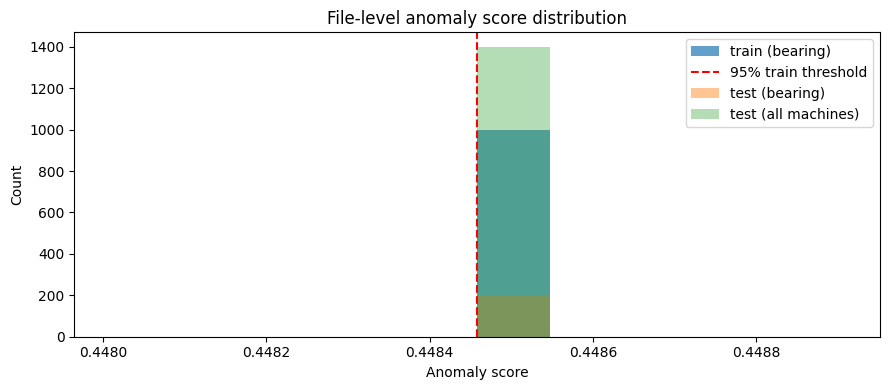

In [ ]:
def anomaly_map_to_file_score(anomaly_map, topk_ratio=0.05):
    flat = anomaly_map.flatten(1)
    k = max(1, int(flat.shape[1] * topk_ratio))
    topk_vals = torch.topk(flat, k=k, dim=1).values
    return topk_vals.mean(dim=1)


def score_file_list(model_obj, file_list, mel_transform, frontend_cfg, topk_ratio=0.05):
    model_obj.eval()
    scores = []

    with torch.no_grad():
        for file_path in file_list:
            waveform = load_waveform(file_path)
            x = waveform_to_model_input(waveform, mel_transform, frontend_cfg).unsqueeze(0).to(device)
            out = model_obj(x, apply_anomaly=False)
            file_score = anomaly_map_to_file_score(out["anomaly_map"], topk_ratio=topk_ratio)
            scores.append(float(file_score.item()))

    return np.asarray(scores, dtype=np.float32)


def infer_label_from_filename(path):
    name = os.path.basename(path).lower()
    if "anomaly" in name:
        return 1
    if "normal" in name:
        return 0
    return None


def compute_auc_metrics(file_paths, scores, tag):
    labels = np.asarray([infer_label_from_filename(p) for p in file_paths], dtype=object)
    valid = np.asarray([lbl is not None for lbl in labels])

    print(f"[{tag}] files scored: {len(file_paths)}")
    print(f"[{tag}] files with inferred labels: {valid.sum()}")

    if valid.sum() == 0:
        print(f"[{tag}] AUROC/pAUC unavailable: no inferred labels.")
        return None, None

    y_true = labels[valid].astype(int)
    y_score = scores[valid].astype(np.float32)

    if len(np.unique(y_true)) < 2:
        print(f"[{tag}] AUROC/pAUC unavailable: labels do not contain both classes.")
        return None, None

    auroc = roc_auc_score(y_true, y_score)
    pauc_01 = roc_auc_score(y_true, y_score, max_fpr=0.1)
    print(f"[{tag}] AUROC: {auroc:.4f}")
    print(f"[{tag}] pAUC@0.1: {pauc_01:.4f}")
    return auroc, pauc_01


def plot_hist_safe(values, label, alpha):
    vals = np.asarray(values, dtype=np.float32)
    if vals.size == 0:
        return

    if np.allclose(vals.min(), vals.max()):
        center = float(vals.mean())
        half_width = max(1e-6, abs(center) * 1e-3)
        bins = np.linspace(center - half_width, center + half_width, 11)
    else:
        bins = "auto"

    plt.hist(x=vals, bins=bins, alpha=alpha, label=label)


# Train distribution: all machine types.
train_scores_v2 = score_file_list(paper_model, train_files_v2, mel_transform_v2, f_cfg, topk_ratio=TOPK_RATIO)
train_threshold = float(np.percentile(train_scores_v2, 95))

print(
    f"[Train:AllMachines] score stats: min={train_scores_v2.min():.4f}, "
    f"mean={train_scores_v2.mean():.4f}, max={train_scores_v2.max():.4f}, "
    f"std={train_scores_v2.std():.4f}"
)
print(f"[Train:AllMachines] threshold (95th percentile): {train_threshold:.4f}")

# Test evaluation: all machine types.
test_files_all = collect_multi_machine_split_files(DATA_ROOT, STAGE2_MACHINE_TYPES, split="test")
if len(test_files_all) == 0:
    print("No multi-machine test files found.")
    test_scores_all = None
else:
    test_scores_all = score_file_list(paper_model, test_files_all, mel_transform_v2, f_cfg, topk_ratio=TOPK_RATIO)
    compute_auc_metrics(test_files_all, test_scores_all, tag="Test:AllMachines")

# Plot score histograms.
plt.figure(figsize=(9, 4))
plot_hist_safe(train_scores_v2, label="train (all machines)", alpha=0.7)
plt.axvline(x=train_threshold, color="red", linestyle="--", label="95% train threshold")

if test_scores_all is not None:
    plot_hist_safe(test_scores_all, label="test (all machines)", alpha=0.5)

plt.title("File-level anomaly score distribution")
plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


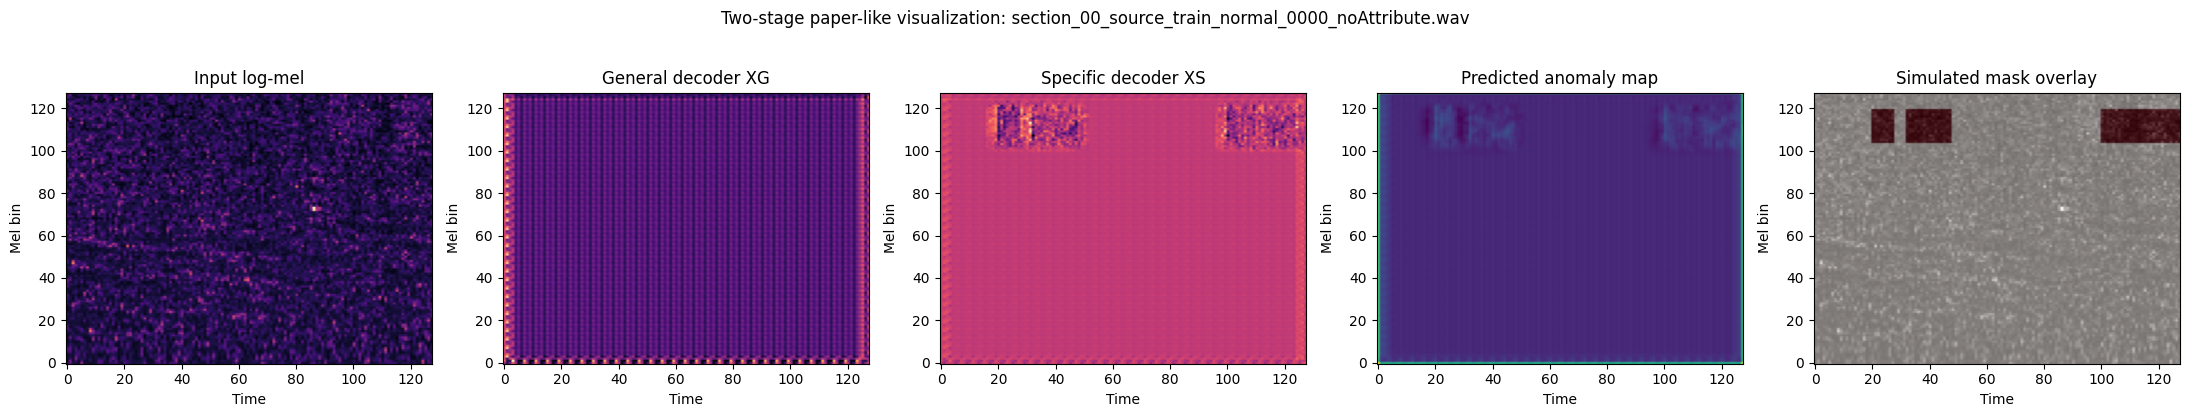

In [ ]:
# Visualize one file from the two-stage paper-like pipeline (randomly from all machines)
if VISUALIZE_INDEX < 0 or VISUALIZE_INDEX >= len(train_files_v2):
    raise IndexError(f"VISUALIZE_INDEX must be in [0, {len(train_files_v2)-1}]")

paper_selected_file = train_files_v2[VISUALIZE_INDEX]
paper_selected_waveform = load_waveform(paper_selected_file)
paper_selected_input = waveform_to_model_input(
    paper_selected_waveform,
    mel_transform_v2,
    f_cfg,
).unsqueeze(0).to(device)

paper_model.eval()
with torch.no_grad():
    # apply_anomaly=True here only for visualization of sampled anomaly regions
    paper_out = paper_model(paper_selected_input, apply_anomaly=True, anomaly_batch_ratio=1.0)

paper_input_img = paper_selected_input.squeeze().detach().cpu().numpy()
paper_general_img = paper_out["x_general"].squeeze().detach().cpu().numpy()
paper_specific_img = paper_out["x_specific"].squeeze().detach().cpu().numpy()
paper_map_img = paper_out["anomaly_map"].squeeze().detach().cpu().numpy()
paper_mask_img = F.interpolate(
    paper_out["mask"].float(),
    size=(SPEC_SIZE, SPEC_SIZE),
    mode="nearest",
).squeeze().detach().cpu().numpy()

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
axes[0].imshow(paper_input_img, origin="lower", aspect="auto", cmap="magma")
axes[0].set_title("Input log-mel")

axes[1].imshow(paper_general_img, origin="lower", aspect="auto", cmap="magma")
axes[1].set_title("General decoder XG")

axes[2].imshow(paper_specific_img, origin="lower", aspect="auto", cmap="magma")
axes[2].set_title("Specific decoder XS")

axes[3].imshow(paper_map_img, origin="lower", aspect="auto", cmap="viridis")
axes[3].set_title("Predicted anomaly map")

axes[4].imshow(paper_input_img, origin="lower", aspect="auto", cmap="gray")
axes[4].imshow(paper_mask_img, origin="lower", aspect="auto", cmap="Reds", alpha=0.45)
axes[4].set_title("Simulated mask overlay")

for ax in axes:
    ax.set_xlabel("Time")
    ax.set_ylabel("Mel bin")

plt.suptitle(f"Two-stage paper-like visualization: {os.path.basename(paper_selected_file)}", y=1.03)
plt.tight_layout()
plt.show()
